## Business Understanding

Цель: Сделать новую версию модели машинного обучения с большей выборкой и лучшими features для достижения метрики R2 > 90%

## Data Understanding

### imports

In [2100]:
from random import Random

import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sqlalchemy.dialects.mssql.information_schema import columns

In [2101]:
df_main = pd.read_excel('data/SO_data.xlsx', sheet_name='so')
df_ms_by_chain = pd.read_excel('data/SO_data.xlsx', sheet_name='ms_by_chain')
df_ms_by_city = pd.read_excel('data/SO_data.xlsx', sheet_name='ms_by_city')
df_pop = pd.read_excel('data/SO_data.xlsx', sheet_name='pop')

### fcs

In [2102]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


def print_info(df, name: str):
    print(f'{"*"*20}')
    print(f'{"="*5} РАЗМЕР {name} {"="*5}')
    print(df.shape)
    print(f'{"="*5} ТИП ДАННЫХ {name} {"="*5}')
    print(df.dtypes)
    print(f'{"="*5} ПРОПУСКИ {name} {"="*5}')
    print(df.isnull().sum())
    print(f'{"="*5} СТАТИСТИКА {name} {"="*5}')
    print(df.describe())
    print(f'{"="*5} ПЕРВЫЕ 5 СТРОК {name} {"="*5}')
    print(df.head())
    print(f'{"*"*20}')


def get_store_share_in_city(row):
    if row['chain'] == 'Ашан':
        return row['ms_by_chain_in_city'] * row['ms_by_city'] * (row['aushan_stores_count'] / row['top_chains_total_count'])
    elif row['chain'] == 'Лента':
        return row['ms_by_chain_in_city'] * row['ms_by_city'] * (row['lenta_stores_count'] / row['top_chains_total_count'])
    elif row['chain'] == 'Детский мир':
        return row['ms_by_chain_in_city'] * row['ms_by_city'] * (row['detmir_stores_count'] / row['top_chains_total_count'])
    else:
        return 0


def evaluate_model(y_true, y_pred, dataset_name):
  mse = mean_squared_error(y_true, y_pred)
  mae = mean_absolute_error(y_true, y_pred)
  rmse = np.sqrt(mse)
  r2 = r2_score(y_true, y_pred)

  print(f'\n---Метрика для {dataset_name} ---')
  print(f'MAE (Средняя абсолютная ошибка): {mae:.2f}')
  print(f'MSE (Средняя квадратичная ошибка): {mse:.2f}')
  print(f'RMSE (Корень из MSE): {rmse:.2f}')
  print(f'R2-score (Коэффициент детерминации): {r2:.4f}')

  return {'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'R2': r2}


### data visualisation

In [2103]:
print_info(df_main, 'df_main')
print_info(df_ms_by_chain, 'df_ms_by_chain')
print_info(df_ms_by_city, 'df_ms_by_city')
print_info(df_pop, 'df_pop')

********************
===== РАЗМЕР df_main =====
(10248, 7)
===== ТИП ДАННЫХ df_main =====
year         int64
id          object
chain       object
city        object
cereals    float64
milks      float64
avg        float64
dtype: object
===== ПРОПУСКИ df_main =====
year         0
id           0
chain        0
city         0
cereals    736
milks       55
avg          0
dtype: int64
===== СТАТИСТИКА df_main =====
               year      cereals         milks           avg
count  10248.000000  9512.000000  10193.000000  1.024800e+04
mean    2023.075332    16.249579     39.525851  3.501562e+05
std        1.380971     9.920923     21.685098  5.085286e+05
min     2021.000000     1.000000      1.000000 -1.947261e+04
25%     2022.000000     6.000000     16.000000  2.547663e+04
50%     2023.000000    16.000000     45.000000  2.394035e+05
75%     2024.000000    25.000000     58.000000  5.141866e+05
max     2025.000000    35.000000     75.000000  1.803045e+07
===== ПЕРВЫЕ 5 СТРОК df_main =====
 

/var/folders/mw/df2fk4ns7js6vrsp3djyzx240000gn/T/ipykernel_22705/944502115.py:43: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1,2].boxplot([df_main['avg'], outliers.dropna()], labels=['Все данные', 'Выбросы'])


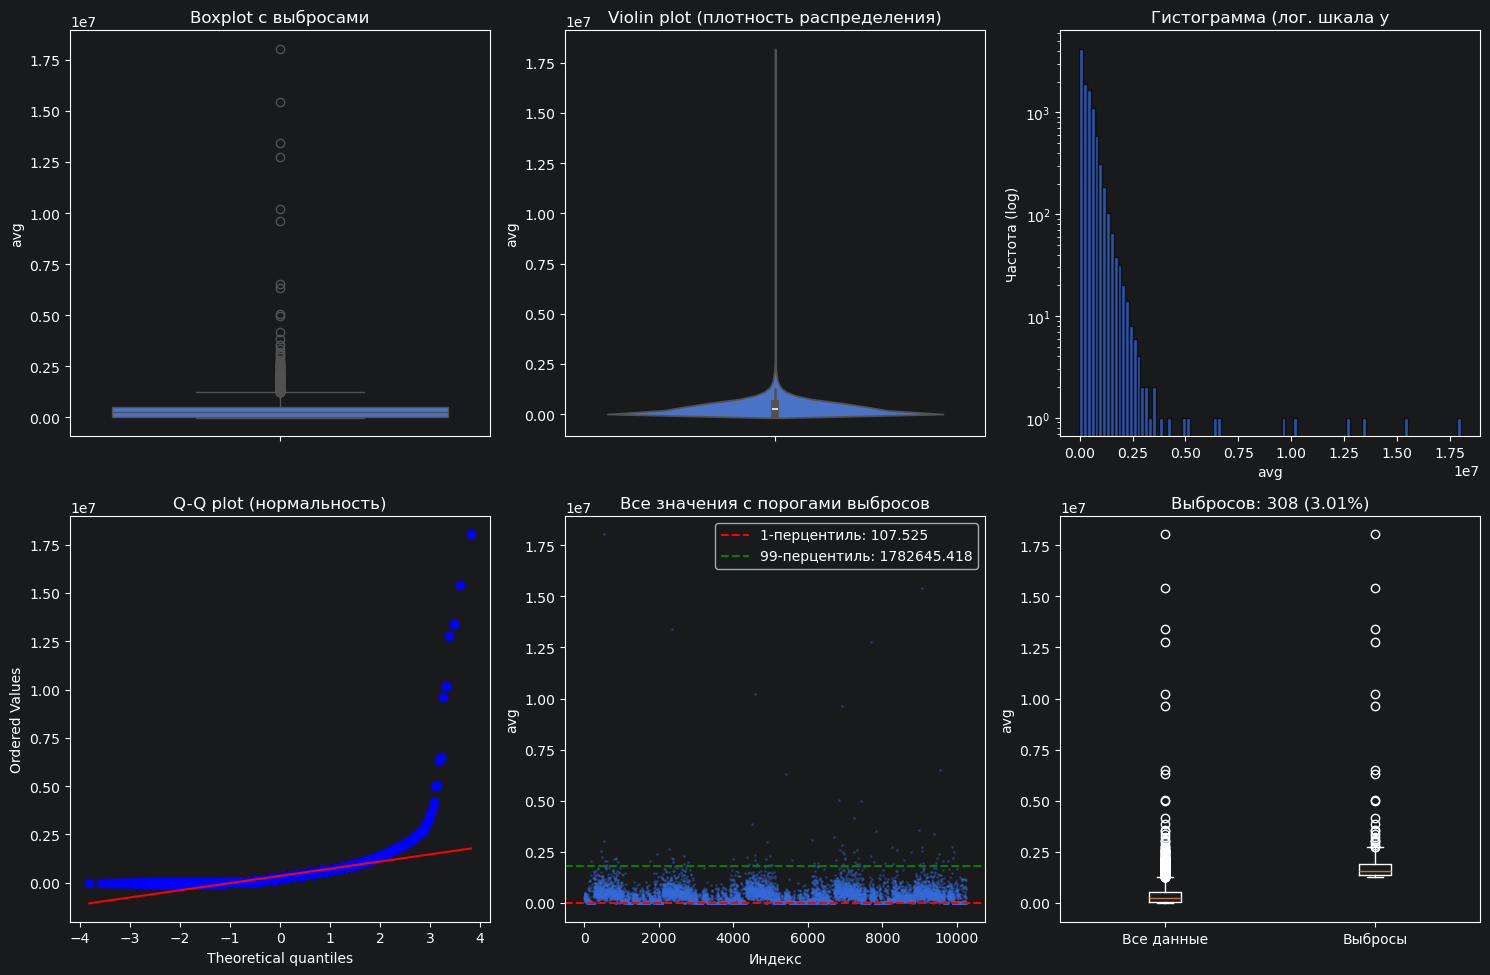

In [2104]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# 1. Boxplot с выбросами
sns.boxplot(y=df_main['avg'], ax=axes[0, 0], showfliers=True)
axes[0, 0].set_title('Boxplot с выбросами')
axes[0, 0].set_ylabel('avg')

# 2. Violin plot
sns.violinplot(y=df_main['avg'], ax=axes[0, 1])
axes[0,1].set_title('Violin plot (плотность распределения)')

# 3. Гистограмма с логарифмической шкалой
axes[0,2].hist(df_main['avg'], bins=100, edgecolor='black', alpha=0.7)
axes[0,2].set_yscale('log')
axes[0,2].set_title('Гистограмма (лог. шкала y')
axes[0,2].set_xlabel('avg')
axes[0,2].set_ylabel('Частота (log)')

# 4. Q-Q plot для проверки нормальности
stats.probplot(df_main['avg'].dropna(), dist='norm', plot=axes[1, 0])
axes[1,0].set_title('Q-Q plot (нормальность)')

# 5. График 'квантиль-значение' для выбросов
q_low = df_main['avg'].quantile(0.01)
q_high = df_main['avg'].quantile(0.99)

axes[1,1].scatter(range(len(df_main['avg'])), df_main['avg'], alpha=0.3, s=1)
axes[1,1].axhline(y=q_low, color='r', linestyle='--', label=f'1-перцентиль: {q_low:.3f}')
axes[1,1].axhline(y=q_high, color='g', linestyle='--', label=f'99-перцентиль: {q_high:.3f}')
axes[1,1].set_title('Все значения с порогами выбросов')
axes[1,1].set_xlabel('Индекс')
axes[1,1].set_ylabel('avg')
axes[1,1].legend()

# 6. Статистика выбросов по IQR
Q1 = df_main['avg'].quantile(0.25)
Q3 = df_main['avg'].quantile(0.75)
IQR = Q3 - Q1
lower_band = Q1 -1.5 * IQR
upper_band = Q3 + 1.5 * IQR

outliers = df_main['avg'][(df_main['avg'] < lower_band) | (df_main['avg'] > upper_band)]
axes[1,2].boxplot([df_main['avg'], outliers.dropna()], labels=['Все данные', 'Выбросы'])
axes[1,2].set_title(f'Выбросов: {len(outliers)} ({len(outliers)/len(df_main)*100:.2f}%)')
axes[1,2].set_ylabel('avg')

plt.tight_layout()

In [2105]:
# Дополнительная числовая статистика выбросов
print("="*50)
print("Статистика по выбросам (IQR метод):")
print(f'Q1 (25%): {Q1:.4f}')
print(f'Q1 (75%): {Q3:.4f}')
print(f'IQR: {IQR:.4f}')
print(f'Нижняя граница: {lower_band:.4f}')
print(f'Верхняя граница: {upper_band:.4f}')
print(f'Количество выбросов: {len(outliers)} (доля: {len(outliers)/len(df_main)*100:.2f}%)')
print(f'Мин значение: {df_main['avg'].min():.4f}')
print(f'Макс значение: {df_main['avg'].max():.4f}')
print(f'Количество отрицательных значений: {len(df_main['avg'][df_main['avg'] < 0])}, '
      f'(доля: {len(df_main['avg'][df_main['avg'] < 0])/len(df_main['avg'])*100:.2f}%)')
print(f'Количество нулевых значений: {len(df_main['avg'][df_main['avg'] == 0])}, '
      f'(доля: {len(df_main['avg'][df_main['avg'] == 0])/len(df_main['avg'])*100:.2f}%)')
print(f'Количество значений более 2 000 000: {len(df_main['avg'][df_main['avg'] > 2000000])} , '
      f'(доля: {len(df_main['avg'][df_main['avg'] > 2000000])/len(df_main['avg'])*100:.2f}%)')
print('='*50)

Статистика по выбросам (IQR метод):
Q1 (25%): 25476.6274
Q1 (75%): 514186.5649
IQR: 488709.9374
Нижняя граница: -707588.2787
Верхняя граница: 1247251.4710
Количество выбросов: 308 (доля: 3.01%)
Мин значение: -19472.6096
Макс значение: 18030452.6361
Количество отрицательных значений: 7, (доля: 0.07%)
Количество нулевых значений: 0, (доля: 0.00%)
Количество значений более 2 000 000: 65 , (доля: 0.63%)


## Data preparation

In [2106]:
# 1. Удаляем отрицательные значения
df_clear = df_main[df_main['avg'] > 0].copy()

# 2. Пересчитываем границы
Q1 = df_clear['avg'].quantile(0.25)
Q3 = df_clear['avg'].quantile(0.75)
IQR = Q3 - Q1
lower_band = Q1 -1.5 * IQR
upper_band = Q3 + 1.5 * IQR

outliers = df_clear['avg'][(df_clear['avg'] < lower_band) | (df_clear['avg'] > upper_band)]

print("="*50)
print("Статистика по выбросам (IQR метод):")
print(f'Q1 (25%): {Q1:.4f}')
print(f'Q3 (75%): {Q3:.4f}')
print(f'IQR: {IQR:.4f}')
print(f'Нижняя граница: {lower_band:.4f}')
print(f'Верхняя граница: {upper_band:.4f}')
print(f'Количество выбросов: {len(outliers)} (доля: {len(outliers)/len(df_clear)*100:.2f}%)')

Статистика по выбросам (IQR метод):
Q1 (25%): 25607.1200
Q3 (75%): 514210.5854
IQR: 488603.4654
Нижняя граница: -707298.0782
Верхняя граница: 1247115.7836
Количество выбросов: 308 (доля: 3.01%)


In [2107]:
# 3. Применяем winsorization ТОЛЬКО к верхней границе
df_clear['avg'] = df_clear['avg'].clip(upper=upper_band)

df_clear['avg'].describe()

count    1.024100e+04
mean     3.284928e+05
std      3.308646e+05
min      9.469394e+00
25%      2.560712e+04
50%      2.398018e+05
75%      5.142106e+05
max      1.247116e+06
Name: avg, dtype: float64

In [2108]:
# 4. Заполняем пропуски 0 в cereals и milks
df_clear['cereals'] = df_clear['cereals'].fillna(0)
df_clear['milks'] = df_clear['milks'].fillna(0)

# 5. Меняем type milks & cereals на целочисленное число
df_clear['cereals'] = df_clear['cereals'].astype(int)
df_clear['milks'] = df_clear['milks'].astype(int)

In [2109]:
df_clear.describe()

,year,cereals,milks,avg
count,10241.000000,10241.000000,10241.000000,1.024100e+04
mean,2023.075676,15.089054,39.333952,3.284928e+05
std,1.381036,10.438720,21.811958,3.308646e+05
min,2021.000000,0.000000,0.000000,9.469394e+00
25%,2022.000000,4.000000,15.000000,2.560712e+04
50%,2023.000000,16.000000,45.000000,2.398018e+05
75%,2024.000000,24.000000,58.000000,5.142106e+05
max,2025.000000,35.000000,75.000000,1.247116e+06


In [2110]:
# Заполняем пустые значения df_ms_by_chain скользящими средними
mask_2024 = df_ms_by_chain['2024'].isna()
df_ms_by_chain.loc[mask_2024, '2024'] = (
    df_ms_by_chain.loc[mask_2024, '2021'] +
    df_ms_by_chain.loc[mask_2024, '2022'] +
    df_ms_by_chain.loc[mask_2024, '2023']
) / 3

mask_2025 = df_ms_by_chain['2025'].isna()
df_ms_by_chain.loc[mask_2025, '2025'] = (
    df_ms_by_chain.loc[mask_2025, '2022'] +
    df_ms_by_chain.loc[mask_2025, '2023'] +
    df_ms_by_chain.loc[mask_2025, '2024']
) / 3

mask_2026 = df_ms_by_chain['2026'].isna()
df_ms_by_chain.loc[mask_2026, '2026'] = (
    df_ms_by_chain.loc[mask_2026, '2023'] +
    df_ms_by_chain.loc[mask_2026, '2024'] +
    df_ms_by_chain.loc[mask_2026, '2025']
) / 3

In [2111]:
print_info(df_ms_by_chain, 'df_ms_by_chain')

********************
===== РАЗМЕР df_ms_by_chain =====
(872, 8)
===== ТИП ДАННЫХ df_ms_by_chain =====
SO City     object
chain       object
2021       float64
2022       float64
2023       float64
2024       float64
2025       float64
2026       float64
dtype: object
===== ПРОПУСКИ df_ms_by_chain =====
SO City    0
chain      0
2021       0
2022       0
2023       0
2024       0
2025       0
2026       0
dtype: int64
===== СТАТИСТИКА df_ms_by_chain =====
             2021        2022        2023        2024        2025        2026
count  872.000000  872.000000  872.000000  872.000000  872.000000  872.000000
mean     0.288781    0.284876    0.287274    0.294193    0.273266    0.294261
std      0.088495    0.087263    0.086761    0.096078    0.088968    0.096568
min      0.019257    0.014442    0.010832    0.000000    0.000000    0.000000
25%      0.230671    0.226865    0.231287    0.232586    0.212168    0.234929
50%      0.283742    0.279388    0.280215    0.293192    0.266993    0.28

In [2112]:
# Заполняем пустые значения df_ms_by_city скользящими средними
mask_2024 = df_ms_by_city['2024'].isna()
df_ms_by_city.loc[mask_2024, '2024'] = (
    df_ms_by_city.loc[mask_2024, '2021'] +
    df_ms_by_city.loc[mask_2024, '2022'] +
    df_ms_by_city.loc[mask_2024, '2023']
) / 3

mask_2025 = df_ms_by_city['2025'].isna()
df_ms_by_city.loc[mask_2025, '2025'] = (
    df_ms_by_city.loc[mask_2025, '2022'] +
    df_ms_by_city.loc[mask_2025, '2023'] +
    df_ms_by_city.loc[mask_2025, '2024']
) / 3

mask_2026 = df_ms_by_city['2026'].isna()
df_ms_by_city.loc[mask_2026, '2026'] = (
    df_ms_by_city.loc[mask_2026, '2023'] +
    df_ms_by_city.loc[mask_2026, '2024'] +
    df_ms_by_city.loc[mask_2026, '2025']
) / 3


In [2113]:
df_pop['population'] = (
    df_pop['population']
    .astype(str)
    .str.replace(',', '')
    .str.replace(' ', '')
    .str.extract(r'(\d+)')
    .astype(float)
    .astype(int)
)

df_pop.isna().sum()

city          0
population    0
dtype: int64

## Features engineering

#### Merge with population

In [2114]:
# Объединяем таблицу SO с population
df_clear = df_clear.merge(df_pop, on='city', how='left')

print_info(df_clear, 'df_clear')

********************
===== РАЗМЕР df_clear =====
(10262, 8)
===== ТИП ДАННЫХ df_clear =====
year            int64
id             object
chain          object
city           object
cereals         int64
milks           int64
avg           float64
population    float64
dtype: object
===== ПРОПУСКИ df_clear =====
year            0
id              0
chain           0
city            0
cereals         0
milks           0
avg             0
population    263
dtype: int64
===== СТАТИСТИКА df_clear =====
               year       cereals         milks           avg    population
count  10262.000000  10262.000000  10262.000000  1.026200e+04  9.999000e+03
mean    2023.075326     15.095011     39.338725  3.285092e+05  2.699096e+06
std        1.381190     10.439930     21.810948  3.307286e+05  4.460979e+06
min     2021.000000      0.000000      0.000000  9.469394e+00  1.010900e+04
25%     2022.000000      4.000000     15.000000  2.554303e+04  1.028400e+05
50%     2023.000000     16.000000     45.00

In [2115]:
# удаляем строки с city без данных о population
df_clear = df_clear[~df_clear['population'].isna()]
print(df_clear.shape)


(9999, 8)


#### Merge with MS by cities

In [2116]:
# Форматируем df MS by cities
df_ms_by_city = df_ms_by_city.melt(
    id_vars=['SO City'],
    value_name='ms_by_city',
    var_name='year',
)

df_ms_by_city = df_ms_by_city.rename(columns={'SO City': 'city'})
df_ms_by_city['year'] = df_ms_by_city['year'].astype(int)

df_ms_by_city.head()

,city,year,ms_by_city
0,Абакан,2021,0.218124
1,Абдулино,2021,0.204541
2,Абинск,2021,0.285089
3,Агалатово,2021,0.471580
4,Агрыз,2021,0.142421


In [2117]:
# Объединяем таблицу SO с MS by cities
df_clear = df_clear.merge(
    df_ms_by_city,
    left_on=['city', 'year'],
    right_on=['city', 'year'],
    how='left',
)

df_clear.head()

,year,id,chain,city,cereals,milks,avg,population,ms_by_city
0,2021,AUC_001,Ашан,Мытищи,22,49,257261.627968,173341.0,0.231450
1,2021,AUC_002,Ашан,Москва,22,50,312484.931144,12655050.0,0.264681
2,2021,AUC_003,Ашан,Марфино,22,49,275175.068125,36742.0,0.228482
3,2021,AUC_004,Ашан,Красногорск,22,48,182340.005856,116738.0,0.274818
4,2021,AUC_005,Ашан,Химки,22,50,296468.844223,207125.0,0.256843


#### Merge with MS by chain

In [2118]:
# Форматируем df MS by chain
df_ms_by_chain = df_ms_by_chain.melt(
    id_vars=['SO City', 'chain'],
    value_name='ms_by_chain_in_city',
    var_name='year',
)

df_ms_by_chain['year'] = df_ms_by_chain['year'].astype(int)

df_ms_by_chain = df_ms_by_chain.rename(columns={'SO City': 'city'})

df_ms_by_chain.head()

,city,chain,year,ms_by_chain_in_city
0,Абакан,Детский Мир,2021,0.218124
1,Абдулино,Детский Мир,2021,0.204541
2,Абинск,Детский Мир,2021,0.285089
3,Агалатово,Лента,2021,0.471580
4,Агрыз,Детский Мир,2021,0.142421


In [2119]:
# Объединяем таблицу SO с MS by chain
df_clear = df_clear.merge(
    df_ms_by_chain,
    on=['city', 'chain', 'year'],
    how='left',
)

df_clear.head()

,year,id,chain,city,cereals,milks,avg,population,ms_by_city,ms_by_chain_in_city
0,2021,AUC_001,Ашан,Мытищи,22,49,257261.627968,173341.0,0.231450,0.141082
1,2021,AUC_002,Ашан,Москва,22,50,312484.931144,12655050.0,0.264681,0.215023
2,2021,AUC_003,Ашан,Марфино,22,49,275175.068125,36742.0,0.228482,0.228482
3,2021,AUC_004,Ашан,Красногорск,22,48,182340.005856,116738.0,0.274818,0.222840
4,2021,AUC_005,Ашан,Химки,22,50,296468.844223,207125.0,0.256843,0.243205


#### making new features

##### chain

In [2120]:
# создаем новые features на основе chain
# общее количество каждой сети в городе и годе
stores_count = df_clear.groupby(['year', 'city', 'chain']).size().reset_index(name='top_stores_count')
stores_count_pivot = stores_count.pivot(
    index=['year', 'city'],
    columns='chain',
    values='top_stores_count'
).reset_index()

stores_count_pivot.columns = ['year', 'city', 'aushan_stores_count', 'detmir_stores_count', 'lenta_stores_count']
stores_count_pivot = stores_count_pivot.fillna(0)

df_clear = df_clear.merge(stores_count_pivot, on=['year', 'city'], how='left')
df_clear.head()

,year,id,chain,city,cereals,milks,avg,population,ms_by_city,ms_by_chain_in_city,aushan_stores_count,detmir_stores_count,lenta_stores_count
0,2021,AUC_001,Ашан,Мытищи,22,49,257261.627968,173341.0,0.231450,0.141082,1.0,7.0,7.0
1,2021,AUC_002,Ашан,Москва,22,50,312484.931144,12655050.0,0.264681,0.215023,26.0,123.0,114.0
2,2021,AUC_003,Ашан,Марфино,22,49,275175.068125,36742.0,0.228482,0.228482,1.0,0.0,0.0
3,2021,AUC_004,Ашан,Красногорск,22,48,182340.005856,116738.0,0.274818,0.222840,1.0,4.0,7.0
4,2021,AUC_005,Ашан,Химки,22,50,296468.844223,207125.0,0.256843,0.243205,1.0,3.0,2.0


In [2121]:
# Создаем общее количество сетей Детский мир Лента и Ашан
df_clear['top_chains_total_count'] = df_clear['aushan_stores_count'] + df_clear['lenta_stores_count'] + df_clear['detmir_stores_count']

df_clear.head()

,year,id,chain,city,cereals,milks,avg,population,ms_by_city,ms_by_chain_in_city,aushan_stores_count,detmir_stores_count,lenta_stores_count,top_chains_total_count
0,2021,AUC_001,Ашан,Мытищи,22,49,257261.627968,173341.0,0.231450,0.141082,1.0,7.0,7.0,15.0
1,2021,AUC_002,Ашан,Москва,22,50,312484.931144,12655050.0,0.264681,0.215023,26.0,123.0,114.0,263.0
2,2021,AUC_003,Ашан,Марфино,22,49,275175.068125,36742.0,0.228482,0.228482,1.0,0.0,0.0,1.0
3,2021,AUC_004,Ашан,Красногорск,22,48,182340.005856,116738.0,0.274818,0.222840,1.0,4.0,7.0,12.0
4,2021,AUC_005,Ашан,Химки,22,50,296468.844223,207125.0,0.256843,0.243205,1.0,3.0,2.0,6.0


In [2122]:
# Создаем кол-во долю сетей Детский мир Лента и Ашан
df_clear['detmir_count_share_in_city'] = df_clear['detmir_stores_count'] / df_clear['top_chains_total_count']
df_clear['lenta_count_share_in_city'] = df_clear['lenta_stores_count'] / df_clear['top_chains_total_count']

df_clear.head()

,year,id,chain,city,cereals,milks,avg,population,ms_by_city,ms_by_chain_in_city,aushan_stores_count,detmir_stores_count,lenta_stores_count,top_chains_total_count,detmir_count_share_in_city,lenta_count_share_in_city
0,2021,AUC_001,Ашан,Мытищи,22,49,257261.627968,173341.0,0.231450,0.141082,1.0,7.0,7.0,15.0,0.466667,0.466667
1,2021,AUC_002,Ашан,Москва,22,50,312484.931144,12655050.0,0.264681,0.215023,26.0,123.0,114.0,263.0,0.467681,0.433460
2,2021,AUC_003,Ашан,Марфино,22,49,275175.068125,36742.0,0.228482,0.228482,1.0,0.0,0.0,1.0,0.000000,0.000000
3,2021,AUC_004,Ашан,Красногорск,22,48,182340.005856,116738.0,0.274818,0.222840,1.0,4.0,7.0,12.0,0.333333,0.583333
4,2021,AUC_005,Ашан,Химки,22,50,296468.844223,207125.0,0.256843,0.243205,1.0,3.0,2.0,6.0,0.500000,0.333333


#### cross-features

In [2123]:
# cereals milk ratio
df_clear['milk_cereals_ratio'] = (df_clear['milks'] + 1) / (df_clear['cereals'] + 1)
df_clear.head()
df_clear.head()

,year,id,chain,city,cereals,milks,avg,population,ms_by_city,ms_by_chain_in_city,aushan_stores_count,detmir_stores_count,lenta_stores_count,top_chains_total_count,detmir_count_share_in_city,lenta_count_share_in_city,milk_cereals_ratio
0,2021,AUC_001,Ашан,Мытищи,22,49,257261.627968,173341.0,0.231450,0.141082,1.0,7.0,7.0,15.0,0.466667,0.466667,2.173913
1,2021,AUC_002,Ашан,Москва,22,50,312484.931144,12655050.0,0.264681,0.215023,26.0,123.0,114.0,263.0,0.467681,0.433460,2.217391
2,2021,AUC_003,Ашан,Марфино,22,49,275175.068125,36742.0,0.228482,0.228482,1.0,0.0,0.0,1.0,0.000000,0.000000,2.173913
3,2021,AUC_004,Ашан,Красногорск,22,48,182340.005856,116738.0,0.274818,0.222840,1.0,4.0,7.0,12.0,0.333333,0.583333,2.130435
4,2021,AUC_005,Ашан,Химки,22,50,296468.844223,207125.0,0.256843,0.243205,1.0,3.0,2.0,6.0,0.500000,0.333333,2.217391


In [2124]:
# particular store share in city
df_clear['particular_store_share_in_city'] = df_clear.apply(get_store_share_in_city, axis=1)

df_clear.head()

,year,id,chain,city,cereals,milks,avg,population,ms_by_city,ms_by_chain_in_city,aushan_stores_count,detmir_stores_count,lenta_stores_count,top_chains_total_count,detmir_count_share_in_city,lenta_count_share_in_city,milk_cereals_ratio,particular_store_share_in_city
0,2021,AUC_001,Ашан,Мытищи,22,49,257261.627968,173341.0,0.231450,0.141082,1.0,7.0,7.0,15.0,0.466667,0.466667,2.173913,0.002177
1,2021,AUC_002,Ашан,Москва,22,50,312484.931144,12655050.0,0.264681,0.215023,26.0,123.0,114.0,263.0,0.467681,0.433460,2.217391,0.005626
2,2021,AUC_003,Ашан,Марфино,22,49,275175.068125,36742.0,0.228482,0.228482,1.0,0.0,0.0,1.0,0.000000,0.000000,2.173913,0.052204
3,2021,AUC_004,Ашан,Красногорск,22,48,182340.005856,116738.0,0.274818,0.222840,1.0,4.0,7.0,12.0,0.333333,0.583333,2.130435,0.005103
4,2021,AUC_005,Ашан,Химки,22,50,296468.844223,207125.0,0.256843,0.243205,1.0,3.0,2.0,6.0,0.500000,0.333333,2.217391,0.010411


In [2125]:
# top chains stores on population covered
df_clear['top_chains_stores_population_covered'] = (
        df_clear['population'] /
        df_clear['top_chains_total_count'])

df_clear.head()

,year,id,chain,city,cereals,milks,avg,population,ms_by_city,ms_by_chain_in_city,aushan_stores_count,detmir_stores_count,lenta_stores_count,top_chains_total_count,detmir_count_share_in_city,lenta_count_share_in_city,milk_cereals_ratio,particular_store_share_in_city,top_chains_stores_population_covered
0,2021,AUC_001,Ашан,Мытищи,22,49,257261.627968,173341.0,0.231450,0.141082,1.0,7.0,7.0,15.0,0.466667,0.466667,2.173913,0.002177,11556.066667
1,2021,AUC_002,Ашан,Москва,22,50,312484.931144,12655050.0,0.264681,0.215023,26.0,123.0,114.0,263.0,0.467681,0.433460,2.217391,0.005626,48118.060837
2,2021,AUC_003,Ашан,Марфино,22,49,275175.068125,36742.0,0.228482,0.228482,1.0,0.0,0.0,1.0,0.000000,0.000000,2.173913,0.052204,36742.000000
3,2021,AUC_004,Ашан,Красногорск,22,48,182340.005856,116738.0,0.274818,0.222840,1.0,4.0,7.0,12.0,0.333333,0.583333,2.130435,0.005103,9728.166667
4,2021,AUC_005,Ашан,Химки,22,50,296468.844223,207125.0,0.256843,0.243205,1.0,3.0,2.0,6.0,0.500000,0.333333,2.217391,0.010411,34520.833333


In [2126]:
# particular store share in city on population
df_clear['particular_store_share_in_city_on_population'] = (
        df_clear['top_chains_stores_population_covered'] *
        df_clear['particular_store_share_in_city'])

df_clear.head()

,year,id,chain,city,cereals,milks,avg,population,ms_by_city,ms_by_chain_in_city,aushan_stores_count,detmir_stores_count,lenta_stores_count,top_chains_total_count,detmir_count_share_in_city,lenta_count_share_in_city,milk_cereals_ratio,particular_store_share_in_city,top_chains_stores_population_covered,particular_store_share_in_city_on_population
0,2021,AUC_001,Ашан,Мытищи,22,49,257261.627968,173341.0,0.231450,0.141082,1.0,7.0,7.0,15.0,0.466667,0.466667,2.173913,0.002177,11556.066667,25.156346
1,2021,AUC_002,Ашан,Москва,22,50,312484.931144,12655050.0,0.264681,0.215023,26.0,123.0,114.0,263.0,0.467681,0.433460,2.217391,0.005626,48118.060837,270.727779
2,2021,AUC_003,Ашан,Марфино,22,49,275175.068125,36742.0,0.228482,0.228482,1.0,0.0,0.0,1.0,0.000000,0.000000,2.173913,0.052204,36742.000000,1918.072075
3,2021,AUC_004,Ашан,Красногорск,22,48,182340.005856,116738.0,0.274818,0.222840,1.0,4.0,7.0,12.0,0.333333,0.583333,2.130435,0.005103,9728.166667,49.646294
4,2021,AUC_005,Ашан,Химки,22,50,296468.844223,207125.0,0.256843,0.243205,1.0,3.0,2.0,6.0,0.500000,0.333333,2.217391,0.010411,34520.833333,359.393848


## Modeling

In [2127]:
df_clear = df_clear.reset_index(drop=True)
X = df_clear.drop(['avg', 'year', 'id', 'city'], axis=1)
y = df_clear['avg']

In [2128]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"\nРазмер обучающей выборки: {X_train.shape}")
print(f"\nРазмер тестовой выборки: {X_test.shape}")


Размер обучающей выборки: (7999, 16)

Размер тестовой выборки: (2000, 16)


In [2129]:
categorical_features = ['chain']
numerical_features = [
    'cereals',
    'milks',
    'avg',
    'population',
    'ms_by_city',
    'ms_by_chain_in_city',
    'aushan_stores_count',
    'detmir_stores_count',
    'lenta_stores_count',
    'top_chains_total_count',
    'detmir_count_share_in_city',
    'lenta_count_share_in_city',
    'milk_cereals_ratio',
    'particular_store_share_in_city',
    'top_chains_stores_population_covered',
    'particular_store_share_in_city_on_population'
]

X_train_encoded = pd.get_dummies(X_train, columns=categorical_features, drop_first=True)
X_test_encoded = pd.get_dummies(X_test, columns=categorical_features, drop_first=True)

X_test_encoded = X_test_encoded.reindex(columns=X_train_encoded.columns, fill_value=0)
print('Размерность после кодирования')
print(f'X_train: {X_train_encoded.shape}')
print(f'X_test: {X_test_encoded.shape}')

print(X_test_encoded.columns.to_list)

Размерность после кодирования
X_train: (7999, 17)
X_test: (2000, 17)
<bound method IndexOpsMixin.tolist of Index(['cereals', 'milks', 'population', 'ms_by_city', 'ms_by_chain_in_city',
       'aushan_stores_count', 'detmir_stores_count', 'lenta_stores_count',
       'top_chains_total_count', 'detmir_count_share_in_city',
       'lenta_count_share_in_city', 'milk_cereals_ratio',
       'particular_store_share_in_city',
       'top_chains_stores_population_covered',
       'particular_store_share_in_city_on_population', 'chain_Детский мир',
       'chain_Лента'],
      dtype='object')>


In [2130]:
scaler = StandardScaler()

In [2131]:
X_train_scaled = scaler.fit_transform(X_train_encoded)
X_test_scaled = scaler.transform(X_test_encoded)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train_encoded.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test_encoded.columns)

In [2132]:
rf_model = RandomForestRegressor(
    n_estimators=400,
    random_state=42,
    max_depth=9,
    max_features=0.7,
    min_samples_split=3,
    min_samples_leaf=1,
    max_samples=0.75,
    n_jobs=-1
)

rf_model.fit(X_train_scaled, y_train)

,n_estimators,400
,criterion,'squared_error'
,max_depth,9
,min_samples_split,3
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,0.7
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [2133]:
y_train_pred = rf_model.predict(X_train_scaled)
y_test_pred = rf_model.predict(X_test_scaled)

In [2134]:
train_metrics = evaluate_model(y_train, y_train_pred, 'Обучающей выборки')
test_metrics = evaluate_model(y_test, y_test_pred, 'Тестовой выборки')


---Метрика для Обучающей выборки ---
MAE (Средняя абсолютная ошибка): 84700.12
MSE (Средняя квадратичная ошибка): 18788782700.23
RMSE (Корень из MSE): 137072.18
R2-score (Коэффициент детерминации): 0.8268

---Метрика для Тестовой выборки ---
MAE (Средняя абсолютная ошибка): 100504.53
MSE (Средняя квадратичная ошибка): 26257778946.55
RMSE (Корень из MSE): 162042.52
R2-score (Коэффициент детерминации): 0.7716


In [2135]:
# Анализ важности признаков
feature_importance = pd.DataFrame({
  'feature': X_train_encoded.columns,
  'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\n--- Топ-10 наиболее важных признаков ---")
print(feature_importance.head(10))


--- Топ-10 наиболее важных признаков ---
                                         feature  importance
1                                          milks    0.547065
0                                        cereals    0.117353
3                                     ms_by_city    0.090214
4                            ms_by_chain_in_city    0.053440
13          top_chains_stores_population_covered    0.039224
2                                     population    0.038990
11                            milk_cereals_ratio    0.033126
14  particular_store_share_in_city_on_population    0.013303
15                             chain_Детский мир    0.012159
10                     lenta_count_share_in_city    0.010650


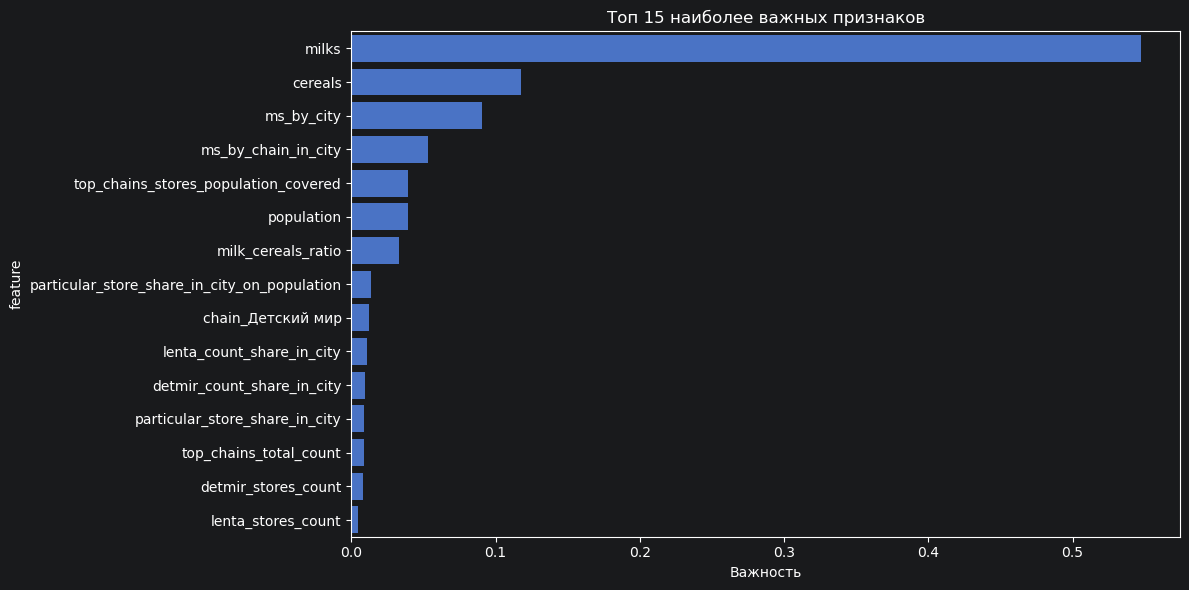

In [2136]:
# Визуализация важности признаков
plt.figure(figsize=(12, 6))
sns.barplot(data=feature_importance.head(15), x='importance', y='feature')
plt.title('Топ 15 наиболее важных признаков')
plt.xlabel('Важность')
plt.tight_layout()
plt.show()

In [2137]:
# # 8. Простая настройка гиперпараметров (опционально)
# print("\n--- Поиск лучших гиперпараметров ---")
#
# # Создаем простую стеку параметров
# param_grid = {
#     'n_estimators': [250, 300, 350, 400],
#     'max_depth': [8, 9, 10, 11],
#     'min_samples_split': [2, 3, 4],
#     'min_samples_leaf': [1, 2, 3],
#     'max_features': ['sqrt', 0.7, 0.8],
#     'max_samples': [0.55, 0.65, 0.75]
# }
#
# # Создаем модель для поиска
# rf_grid = RandomForestRegressor(random_state=42, n_jobs=-1)
#
# # GridSearchCV с кросс-валидацией
# grid_search = GridSearchCV(
#   rf_grid,
#   param_grid,
#   cv=3,
#   scoring='r2',
#   n_jobs=-1,
#   verbose=1
# )
#
# # Обучаем поиск
# grid_search.fit(X_train_scaled, y_train)
#
# print(f'Лучшие параметры: {grid_search.best_params_}')
# print(f'Лучший R2 на кросс-валидации : {grid_search.best_score_:.4f}')